## Market Microstructure

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

params = {
    'S0': 45.0,
    'sigma': 0.6, #（Euro*day^0.5 -> annual volatility of 21%)
    'T': 63, # Trading days
    'F': 900000000, 
    'gamma': 1e-6,      
    'alpha': 0.25,      
    'beta': 0.05,      
    'kappa': 0.005,      
    'n_trajectories': 1024, 
}

V = 4000000
C = 0.01/params['F']
pretraining = 100
def generate_torch_price_paths(p):
    # S_{n+1} = S_n + sigma * sqrt(dt) * epsilon
    S = torch.zeros((p['T'] + 1, p['n_trajectories']))
    S[0] = p['S0']
    for t in range(1, p['T'] + 1):
        epsilon = torch.randn(p['n_trajectories'])
        S[t] = S[t-1] + p['sigma'] * epsilon
    return S

def specialized_S_function(x):
    """
    min(max( 2 / (1 + exp(-x)) - 0.5, 0), 1)
    """
    sigmoid_part = 2.0 / (1.0 + torch.exp(-x)) - 0.5
    return torch.clamp(sigmoid_part, min=0.0, max=1.0)

def calculate_liquidity_cost(rho):
    # L(x)
    return torch.abs(rho)**(1.75)*0.1

def l(x, epoch):
    
    if epoch < pretraining:
        
        C = 0.01 / params['F']
    else:
        C = 2e-9
    return C * (x**2)

def calculate_pnl_step(X, q, A_market, p,epoch):
    # PnL = -penalty + alpha*(Profit)+ - beta*(Loss)-
    excess = q * (A_market - p['kappa'] * p['S0']) - p['F']
    profit_part = p['alpha'] * torch.clamp(excess, min=0)
    loss_part = p['beta'] * torch.clamp(-excess, min=0)  
    return   -l(p['F']-X,epoch)+profit_part - loss_part


class TradingPolicy(nn.Module):
    def __init__(self):
        super(TradingPolicy, self).__init__()
        
        # 1. v_tilde (v_theta)
        # inputs: n/N, S/S0, (A-S)/S0, X/F, qS0/F 
        self.v_net = nn.Sequential(
            nn.Linear(5, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
           
        )
        
        # 2. p_tilde (p_phi)
        # inputs: n/N, S/S0, (A-S)/S0, qS0/F 
        self.p_net = nn.Sequential(
            nn.Linear(4, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
        )
        nn.init.constant_(self.p_net[2].bias, 0.1)
        nn.init.xavier_uniform_(self.p_net[2].weight)
        # 3. nu_phi
        # p_phi = 1_{n \in N} * S(nu_phi * (X/F - p_tilde))
        self.nu = nn.Parameter(torch.tensor([1.0]))

    def forward_v(self, state_v):
        """state_v: (batch, 5) """
        return self.v_net(state_v).squeeze(-1)

    def forward_p(self, state_p):
        """state_p: (batch, 4) """
        return self.p_net(state_p).squeeze(-1)

# 4
model = TradingPolicy() 
optimizer = torch.optim.Adam([
    {'params': model.v_net.parameters(), 'lr': 1e-2},  
    {'params': model.p_net.parameters(), 'lr': 1e-3},  
    {'params': [model.nu], 'lr': 1e-2},                
])
A_market = torch.zeros(params['n_trajectories']) 
torch.manual_seed(123)
for epoch in range(5000):
    S = generate_torch_price_paths({**params, 'n_trajectories': params['n_trajectories']})
    N = params['T']
    F = params['F']
    S0 = params['S0']

    X = torch.zeros(params['n_trajectories']) 
    q = torch.zeros(params['n_trajectories']) 
    v_n = torch.zeros(params['n_trajectories']) 
    #A = torch.zeros(params['n_trajectories'])

    all_p_n = []
    all_pnl_n = []
    A_market = torch.zeros(params['n_trajectories'])   

    for n in range(1, params['T'] + 1):

        A_market = A_market * (n-1) / n + S[n] / n
        
        
        state = torch.stack([
            torch.full((params['n_trajectories'],), n / params['T'] - 0.5),
            S[n] / params['S0'] - 1.0,
            (A_market - S[n]) / params['S0'],
            X / F - 0.5,
            q * params['S0'] / F - 0.5
        ], dim=1)

        state_p = torch.stack([
            torch.full((params['n_trajectories'],), n / params['T'] - 0.5),
            S[n] / params['S0'] - 1.0,
            (A_market - S[n]) / params['S0'],
            q * params['S0'] / F - 0.5,
        ], dim=1)

        v_tilde = model.forward_v(state)
        rate_multiplier = torch.clamp((1 + v_tilde) / max(params['T'] - n, 1), min=0.0, max=1.0)
        v_n = torch.where(X < F,
                        rate_multiplier * (F - X) / S[n],
                        torch.zeros_like(rate_multiplier))
        X = X+ v_n * S[n] + calculate_liquidity_cost(v_n / V) * V 
        q = q+ v_n
        if 22 <= n <= 62:
            x = model.nu * (X / F - model.forward_p(state_p))
            
            p_n = specialized_S_function(x)
           
        elif n == params['T']:
            p_n = torch.ones(params['n_trajectories']) 
        else:
            p_n = torch.zeros(params['n_trajectories']) 
        
        all_p_n.append(p_n)
        all_pnl_n.append(calculate_pnl_step(X, q, A_market, params,epoch))

    if epoch % 100 == 0:
        
        with torch.no_grad():
         
            for n_check in [20, 35, 50]:
                A_check = S[1:n_check+1].mean(dim=0)
                state_check = torch.stack([
                    torch.full((params['n_trajectories'],), n_check / N - 0.5),
                    S[n_check] / S0 - 1.0,
                    (A_check - S[n_check]) / S0,
                    torch.zeros(params['n_trajectories']),  
                    torch.zeros(params['n_trajectories']),  
                ], dim=1)
                v_check = model.forward_v(state_check)
                mask_bad  = S[n_check] > A_check
                mask_good = S[n_check] < A_check
                print(f"n={n_check} | v_tilde(S>A)={v_check[mask_bad].mean():.3f} | "
                    f"v_tilde(S<A)={v_check[mask_good].mean():.3f} | "
                    
                    f"diff={v_check[mask_good].mean()-v_check[mask_bad].mean():.3f}")
            print(f"X/F = {(X/F).mean():.4f}")

            print(f"nu = {model.nu.item():.3f}")
      
            state_p_check = torch.stack([
                torch.full((params['n_trajectories'],), 50 / N - 0.5),
                S[50] / S0 - 1.0,
                (A_market - S[50]) / S0,
                q * S0 / F - 0.5,
            ], dim=1)
            p_tilde_val = model.forward_p(state_p_check)
            p_val = specialized_S_function(model.nu * (X / F - p_tilde_val))
           
            mask_good = A_market > S[N]
            mask_bad  = A_market < S[N]
        
            print(f"平均行使时间: {(weights * torch.arange(1, 64).float()).sum(dim=1).mean():.1f}")

            print(f"p_tilde mean = {p_tilde_val.mean():.3f}")
            print(f"nu*(X/F - p_tilde) mean = {(model.nu*(X/F - p_tilde_val)).mean():.3f}")
            print(f"p_n mean = {p_val.mean():.4f}")

    # Loss
    all_p_n = torch.stack(all_p_n, dim=1)
    all_pnl_n = torch.stack(all_pnl_n, dim=1)
    
    not_exercised = 1 - all_p_n
    cum_prod = torch.cumprod(not_exercised+ 1e-8, dim=1)

    survival = torch.cat([
        torch.ones(params['n_trajectories'], 1).to(all_p_n.device), 
        cum_prod[:, :-1]
    ], dim=1)

    weights = survival * all_p_n

    path_pnls = torch.sum(weights * all_pnl_n, dim=1)
        
    expected_pnl = torch.mean(path_pnls)
    variance_pnl = torch.var(path_pnls)
    gamma = params['gamma']
    if epoch<pretraining:
        gamma = 0
    objective = expected_pnl - (gamma / 2) * variance_pnl

    loss = -objective
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.p_net.parameters(), max_norm=1.0)
    
    optimizer.step()
    if epoch % 100 == 0:
        for name, param in model.named_parameters():
            if 'p_net' in name:
                if param.grad is not None:
                    print(f"{name}: grad_norm={param.grad.norm():.6f}")
                else:
                    print(f"{name}: NO GRAD")
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Mean PnL: {expected_pnl.item():.4f}, Var PnL: {variance_pnl.item():.4f}")

n=20 | v_tilde(S>A)=-0.036 | v_tilde(S<A)=-0.039 | diff=-0.003
n=35 | v_tilde(S>A)=-0.027 | v_tilde(S<A)=-0.031 | diff=-0.004
n=50 | v_tilde(S>A)=-0.021 | v_tilde(S<A)=-0.026 | diff=-0.005
X/F = 0.9999
nu = 1.000
平均行使时间: 44.9
p_tilde mean = 0.108
nu*(X/F - p_tilde) mean = 0.892
p_n mean = 0.9186
p_net.0.weight: grad_norm=0.099163
p_net.0.bias: grad_norm=0.472782
p_net.2.weight: grad_norm=0.737344
p_net.2.bias: grad_norm=0.472195
Epoch 0, Loss: 32499244.0000, Mean PnL: -32499244.0000, Var PnL: 1252936448.0000
Epoch 10, Loss: 18336712.0000, Mean PnL: -18336712.0000, Var PnL: 20366088192.0000
Epoch 20, Loss: 9740059.0000, Mean PnL: -9740059.0000, Var PnL: 92967829504.0000
Epoch 30, Loss: 4397560.5000, Mean PnL: -4397560.5000, Var PnL: 270395277312.0000
Epoch 40, Loss: 1618371.5000, Mean PnL: -1618371.5000, Var PnL: 555539955712.0000
Epoch 50, Loss: 332733.7188, Mean PnL: -332733.7188, Var PnL: 2507301453824.0000
Epoch 60, Loss: -496765.8125, Mean PnL: 496765.8125, Var PnL: 6218851549184.0

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
n=45, v_tilde(S>A) mean=nan


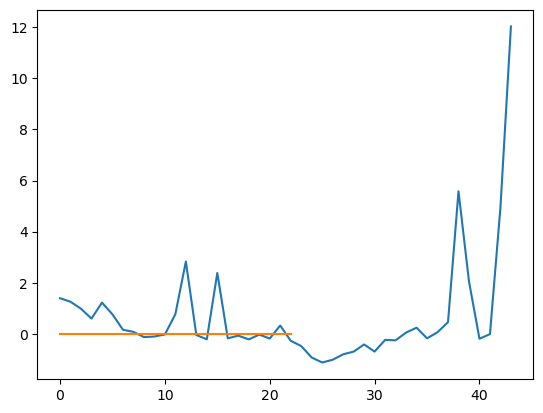

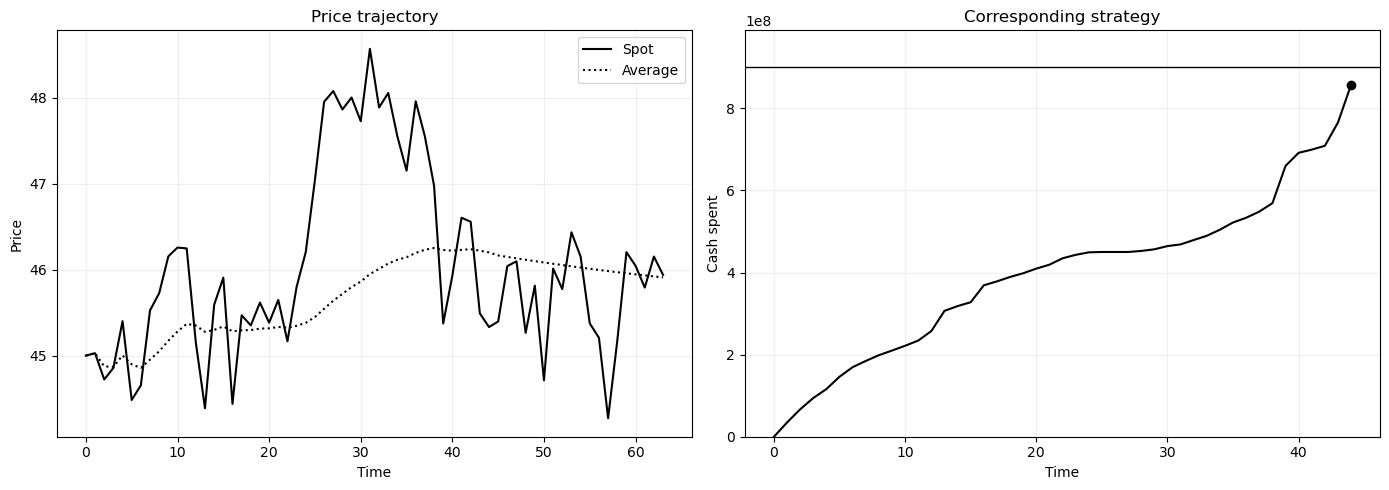

In [18]:
def plot_strategy_results(model, params):
    # 1
    #torch.manual_seed(42) 
    S = generate_torch_price_paths({**params, 'n_trajectories': 1})
    N = params['T']
    F = params['F']
    S0 = params['S0']
    v_his = []
    p_his = []
    # 2. 
    X_history = [0.0]
    A_history = [params['S0']]
    X, q, A_market = torch.tensor([0.0]), torch.tensor([0.0]), torch.tensor([S0])
    v_n = torch.tensor([0.0])
    model.eval() 
    with torch.no_grad():
        for n in range(1, N + 1):
            
            A_market = A_market * (n-1) / n + S[n] / n
            
            
            state = torch.stack([
                torch.full((1,), n / params['T'] - 0.5),
                S[n] / params['S0'] - 1.0,
                (A_market - S[n]) / params['S0'],
                
                X / F - 0.5,
                q * params['S0'] / F - 0.5
            ], dim=1)

            state_p = torch.stack([
                torch.full((1,), n / params['T'] - 0.5),
                S[n] / params['S0'] - 1.0,
                (A_market - S[n]) / params['S0'],
                q * params['S0'] / F - 0.5,
            ], dim=1)

            v_tilde = model.forward_v(state)
            rate_multiplier = torch.clamp((1 + v_tilde) / max(params['T'] - n, 1), min=0.0, max=1.0)
            v_n = torch.where(X < F,
                            rate_multiplier * (F - X) / S[n],
                            torch.zeros_like(rate_multiplier))

            if 22 <= n <= 62 and np.random.uniform(0,1)<specialized_S_function(model.nu * (X / F - model.forward_p(state_p))):
                break
            if 22 <= n <= 62:
                p_his.append(specialized_S_function(model.nu * (X / F - model.forward_p(state_p))).item())
            X =X+ v_n * S[n] + calculate_liquidity_cost(v_n / V) * V 
            q =q+ v_n
            #A = torch.where(new_q > 0, (A * q + S[n] * v_n) / new_q, A)
            v_his.append( v_tilde.item())
            X_history.append(X.item())
            A_history.append(A_market.item())
        print(p_his)
        plt.plot(v_his)
        plt.plot(p_his)
        for _ in range(len(A_history),N+1):
            A_market = A_market * (n-1) / n + S[n] / n
            A_history.append(A_market.item())
            
            
    with torch.no_grad():
        mask = S[n] > A_market  
        print(f"n={n}, v_tilde(S>A) mean={v_tilde[mask].mean():.3f}")
    
            
    # 3
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    days = range(N + 1)
    ax1.plot(days, S.squeeze().numpy(), color='black', label='Spot')
    ax1.plot(days, A_history, color='black', linestyle=':', label='Average')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price')
    ax1.set_title('Price trajectory')
    ax1.legend()
    ax1.grid(True, alpha=0.2)

    # --- cash spent ---
    ax2.plot(days[:len(X_history)], X_history, color='black')
    ax2.axhline(y=F, color='black', linewidth=1) # F

    ax2.scatter(days[len(X_history)-1], X_history[-1], color='black', zorder=5)
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Cash spent')
    ax2.set_title('Corresponding strategy')
    ax2.set_ylim(0, F * 1.1) 
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
   
plot_strategy_results(model, params)